In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("netflix_titles.csv")

df.head()

pd.__version__

'2.3.3'

In [40]:
df.shape


(8807, 11)

In [47]:
df.head()

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknow,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,Unknow,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   cast          7982 non-null   object
 4   country       8807 non-null   object
 5   date_added    8797 non-null   object
 6   release_year  8807 non-null   int64 
 7   rating        8803 non-null   object
 8   duration      8804 non-null   object
 9   listed_in     8807 non-null   object
 10  description   8807 non-null   object
dtypes: int64(1), object(10)
memory usage: 757.0+ KB


In [53]:
df.isnull().sum()

show_id           0
type              0
title             0
cast            825
country           0
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [57]:
(df.isnull().mean() * 100).sort_values(ascending=False)

cast            9.367549
date_added      0.113546
rating          0.045418
duration        0.034064
title           0.000000
show_id         0.000000
type            0.000000
release_year    0.000000
country         0.000000
listed_in       0.000000
description     0.000000
dtype: float64

In [72]:
resumen_nulls = pd.DataFrame({
    "total_filas": len(df),
    "no_null": df.count(),
    "nulls": df.isnull().sum(),
    "porcentaje_null": (df.isnull().mean() * 100).round(2)
})

resumen_nulls.sort_values("porcentaje_null", ascending=False)


,total_filas,no_null,nulls,porcentaje_null
cast,8807,7982,825,9.37
date_added,8807,8797,10,0.11
rating,8807,8803,4,0.05
duration,8807,8804,3,0.03
title,8807,8807,0,0.00
show_id,8807,8807,0,0.00
type,8807,8807,0,0.00
release_year,8807,8807,0,0.00
country,8807,8807,0,0.00
listed_in,8807,8807,0,0.00


In [74]:
total = len(df)
cast_nulls = df["cast"].isna().sum()
cast_pct = (cast_nulls / total) * 100

print(f"Total filas: {total}")
print(f"cast nulos: {cast_nulls} ({cast_pct:.2f}%)")


df["cast_missing"] = df["cast"].isna()

df_cast = df.loc[~df["cast_missing"]].copy()

print(f"Filas disponibles para análisis de cast: {len(df_cast)}")


display(df.loc[df["cast_missing"], ["show_id", "type", "title", "country", "release_year"]].head(10))
display(df_cast[["show_id", "type", "title", "cast", "country", "release_year"]].head(5))


Total filas: 8807
cast nulos: 825 (9.37%)
Filas disponibles para análisis de cast: 7982


,show_id,type,title,country,release_year
0,s1,Movie,Dick Johnson Is Dead,United States,2020
3,s4,TV Show,Jailbirds New Orleans,Unknow,2021
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknow,2021
14,s15,TV Show,Crime Stories: India Detectives,Unknow,2021
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,Unknow,2020
20,s21,TV Show,Monsters Inside: The 24 Faces of Billy Milligan,Unknow,2021
45,s46,Movie,My Heroes Were Cowboys,Unknow,2021
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,India,2014
69,s70,TV Show,Stories by Rabindranath Tagore,India,2015
74,s75,TV Show,The World's Most Amazing Vacation Rentals,Unknow,2021


,show_id,type,title,cast,country,release_year
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021
2,s3,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknow,2021
4,s5,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021
5,s6,TV Show,Midnight Mass,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknow,2021
6,s7,Movie,My Little Pony: A New Generation,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknow,2021


In [76]:
nulls_por_anio = (
    df.groupby("release_year")["cast_missing"]
      .sum()
      .reset_index(name="cast_nulls")
)


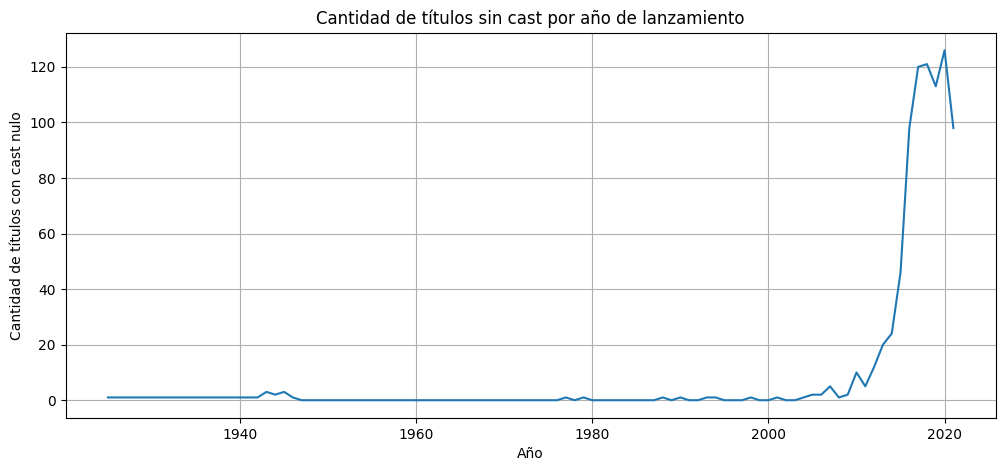

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(
    nulls_por_anio["release_year"],
    nulls_por_anio["cast_nulls"]
)
plt.title("Cantidad de títulos sin cast por año de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad de títulos con cast nulo")
plt.grid(True)
plt.show()





In [97]:
#hacemos una copia para eliminar los paises que estes separados por ","

df_countries = df.copy()

df_countries["country"] = df_countries["country"].fillna("Unknown")
df_countries["country"] = df_countries["country"].str.split(",")
df_countries = df_countries.explode("country")

In [ ]:
df["country_clean"] = df["country"].fillna("Unknown")
df["country_clean"] = df["country_clean"].str.split(",")

df_exploded = df.explode("country_clean")
df_exploded["country_clean"] = df_exploded["country_clean"].str.strip()

df_cast_nulls = df_exploded[df_exploded["cast"].isna()]
nulls_por_pais = (
    df_cast_nulls
    .groupby("country_clean")
    .size()
    .reset_index(name="cast_null")
    .sort_values("cast_null", ascending=False)
)
 nulls_por_pais.head(10)


,country_clean,cast_null
58,United States,407
59,Unknow,154
57,United Kingdom,97
20,India,39
16,France,32
8,Canada,31
51,Spain,23
18,Germany,19
3,Australia,17
31,Mexico,16


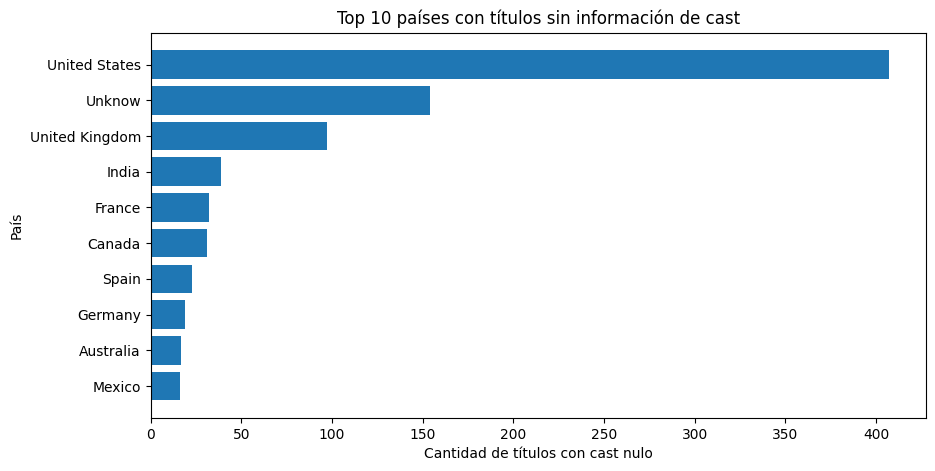

In [103]:
top_paises = nulls_por_pais.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_paises["country_clean"], top_paises["cast_null"])
plt.xlabel("Cantidad de títulos con cast nulo")
plt.ylabel("País")
plt.title("Top 10 países con títulos sin información de cast")
plt.gca().invert_yaxis()
plt.show()


In [109]:
# Copia limpia de country
df["country_clean"] = df["country"].fillna("Unknown").str.split(",")

# Expandir países
df_exploded = df.explode("country_clean")
df_exploded["country_clean"] = df_exploded["country_clean"].str.strip()

# Flag de cast nulo
df_exploded["cast_missing"] = df_exploded["cast"].isna()




## Exploración de valores faltantes (cast)

Durante el análisis exploratorio se identificó que la columna **cast** presenta valores nulos
que no deben ser eliminados ni imputados artificialmente, ya que representan información
categórica no recuperable (nombres propios de actores).

En lugar de eliminar estos registros, los valores nulos se analizan como una **señal de calidad
y completitud del dato**, permitiendo:

- Identificar periodos de tiempo con mayor ausencia de información.
- Analizar diferencias entre países productores.
- Evaluar cambios en la calidad del catálogo de Netflix a lo largo del tiempo.

Este enfoque preserva la integridad del dataset y permite análisis más realistas y trazables.


In [111]:
nulls_year_country = (
    df_exploded[df_exploded["cast_missing"]]
    .groupby(["release_year", "country_clean"])
    .size()
    .reset_index(name="cast_nulls")
)

nulls_year_country.head()


,release_year,country_clean,cast_nulls
0,1925,Unknow,1
1,1942,United States,1
2,1943,United States,3
3,1944,United States,2
4,1945,United States,3


In [113]:
nulls_year_country = nulls_year_country.query("release_year >= 2000")


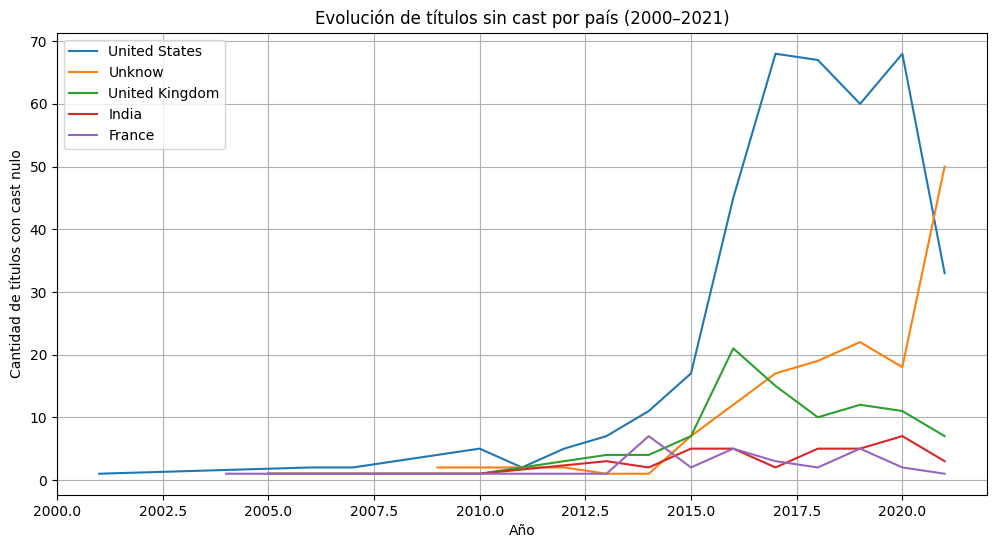

In [114]:
top_countries = (
    nulls_year_country.groupby("country_clean")["cast_nulls"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plot_data = nulls_year_country[
    nulls_year_country["country_clean"].isin(top_countries)
]

plt.figure(figsize=(12,6))

for country in top_countries:
    subset = plot_data[plot_data["country_clean"] == country]
    plt.plot(subset["release_year"], subset["cast_nulls"], label=country)

plt.title("Evolución de títulos sin cast por país (2000–2021)")
plt.xlabel("Año")
plt.ylabel("Cantidad de títulos con cast nulo")
plt.legend()
plt.grid(True)
plt.show()
